In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
print("Loading CIFAR-10 Dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

Loading CIFAR-10 Dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [ ]:
def build_model(hp):
    """
    Builds a CNN model with hyperparameters accessible by the tuner.
    """
    model = keras.Sequential()

    # Input Layer (CIFAR-10 images are 32x32 RGB)
    model.add(layers.Input(shape=(32, 32, 3)))

    # --- Convolutional Block 1 ---
    # Tune the number of filters in the first block
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # --- Convolutional Block 2 ---
    # Tune the number of filters in the second block
    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=32)
    model.add(layers.Conv2D(filters=hp_filters_2, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # --- Convolutional Block 3 (Optional) ---
    # Let the tuner decide if we need a 3rd block
    if hp.Boolean('conv_block_3'):
        hp_filters_3 = hp.Int('filters_3', min_value=64, max_value=256, step=32)
        model.add(layers.Conv2D(filters=hp_filters_3, kernel_size=3, activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output to feed into Dense layers
    model.add(layers.Flatten())

    # --- Dense Layers ---
    # Tune the number of units in the Dense layer
    hp_units = hp.Int('units', min_value=128, max_value=512, step=64)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Tune the Dropout rate to prevent overfitting
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))

    # Output Layer (10 classes for CIFAR-10)
    model.add(layers.Dense(10, activation='softmax'))

    # --- Compilation ---
    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,            # Max epochs per trial
    factor=3,
    directory='my_dir',       # Directory to save logs
    project_name='cifar10_cnn_tuning'
)

# A callback to stop training early if validation loss stops improving
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("\nStarting Hyperparameter Search...")
tuner.search(x_train, y_train,
             epochs=10,
             validation_split=0.2,
             callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
\n--- TUNING COMPLETE ---
Optimal Hyperparameters:
- Filters Block 1: {best_hps.get('filters_1')}
- Filters Block 2: {best_hps.get('filters_2')}
- Use Block 3: {best_hps.get('conv_block_3')}
- Dense Units: {best_hps.get('units')}
- Dropout Rate: {best_hps.get('dropout')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 30 Complete [00h 01m 16s]
val_accuracy: 0.6425999999046326

Best val_accuracy So Far: 0.7735000252723694
Total elapsed time: 00h 20m 35s


--- TUNING COMPLETE ---
Optimal Hyperparameters:
- Filters Block 1: 96
- Filters Block 2: 256
- Use Block 3: True
- Dense Units: 512
- Dropout Rate: 0.2
- Learning Rate: 0.001



In [ ]:
print("\nBuilding and training the best model...")
model = tuner.hypermodel.build(best_hps)

# Train for more epochs to get maximum performance
history = model.fit(x_train, y_train,
                    epochs=20,
                    validation_split=0.2,
                    callbacks=[stop_early])


Building and training the best model...
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.4246 - loss: 1.8386 - val_accuracy: 0.5160 - val_loss: 1.3695
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6434 - loss: 1.0099 - val_accuracy: 0.6690 - val_loss: 0.9333
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7255 - loss: 0.7902 - val_accuracy: 0.6551 - val_loss: 1.0384
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7746 - loss: 0.6456 - val_accuracy: 0.6878 - val_loss: 0.9487
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8199 - loss: 0.5235 - val_accuracy: 0.6638 - val_loss: 1.0317



Evaluating on Test Set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6675 - loss: 1.0553
Test Accuracy: 0.6658


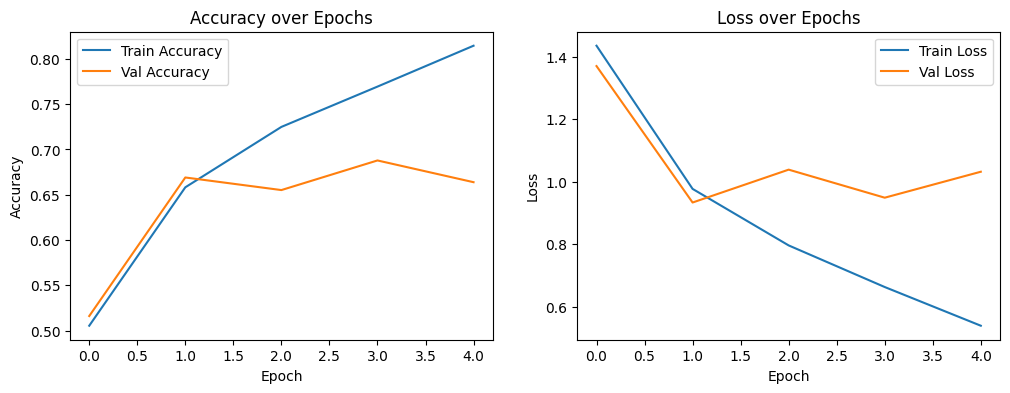

In [ ]:
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


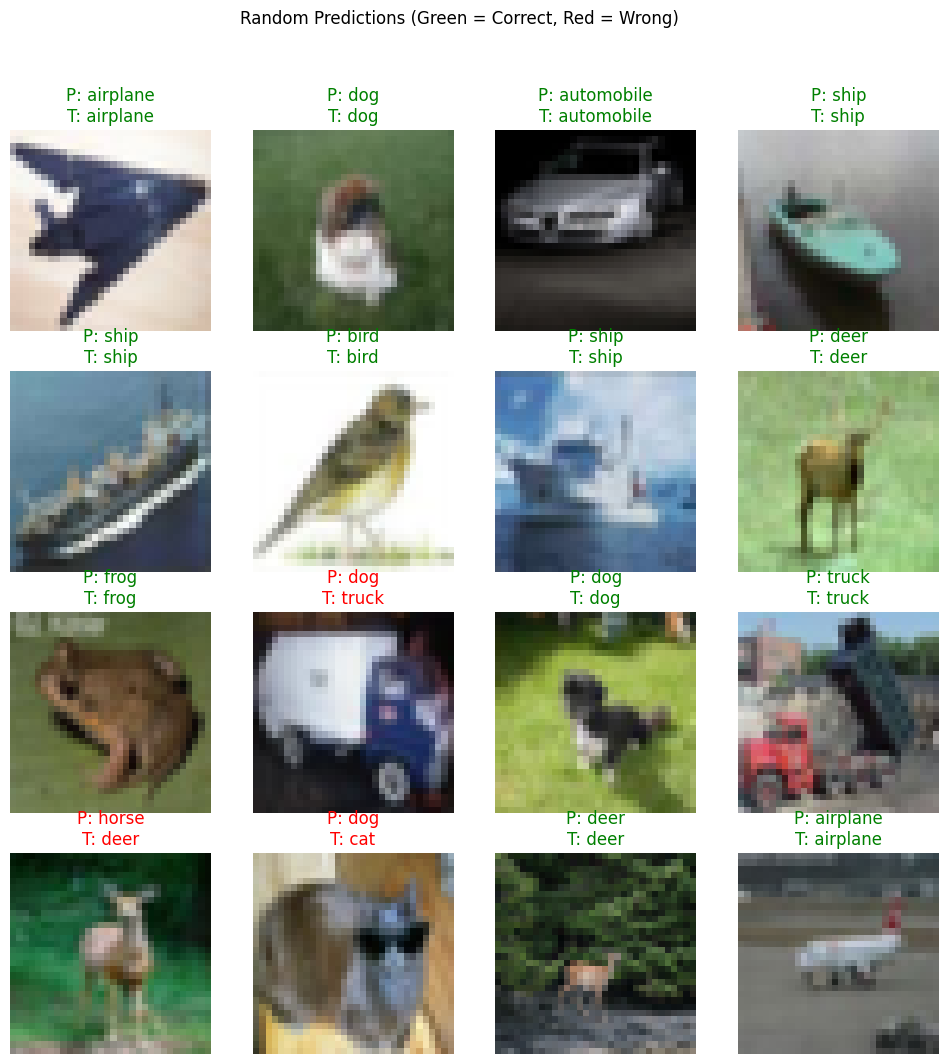

In [ ]:
# Predict on test set
pred_probs = model.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = y_test.flatten()

plt.figure(figsize=(12, 12))

for i in range(16):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[idx])

    color = "green" if pred_labels[idx] == true_labels[idx] else "red"
    plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[true_labels[idx]]}",
              color=color)
    plt.axis("off")

plt.suptitle("Random Predictions (Green = Correct, Red = Wrong)")
plt.show()

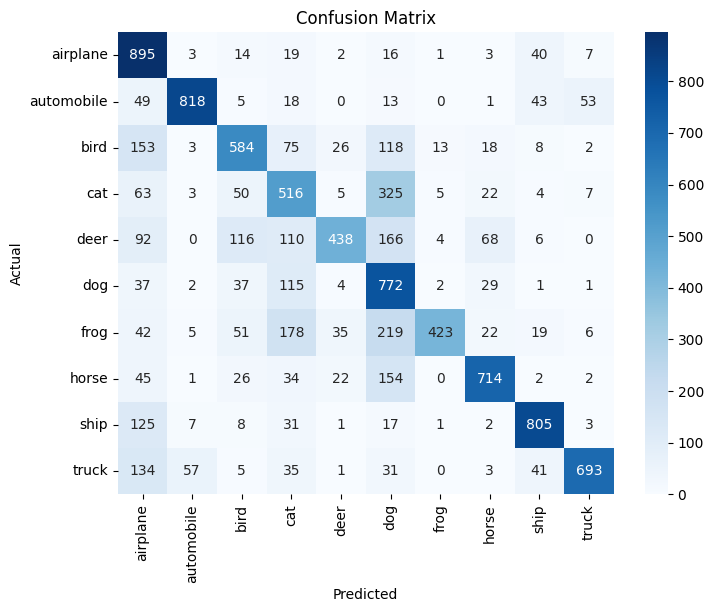

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

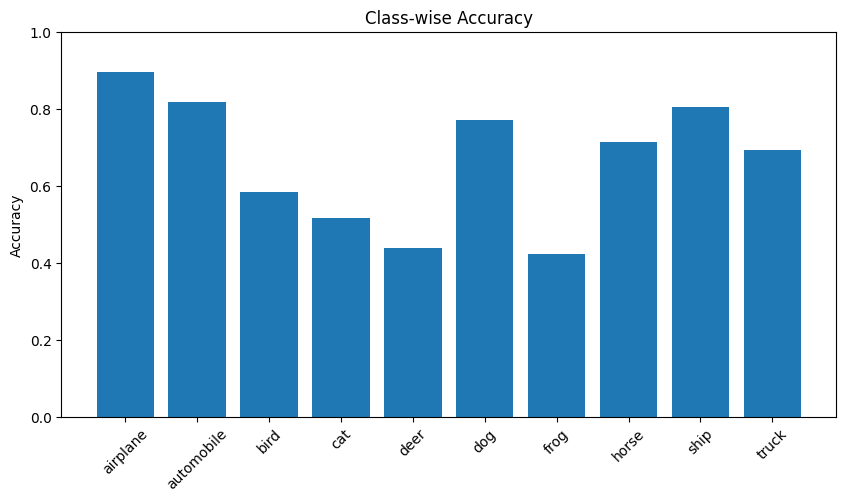

In [ ]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.xticks(rotation=45)
plt.show()

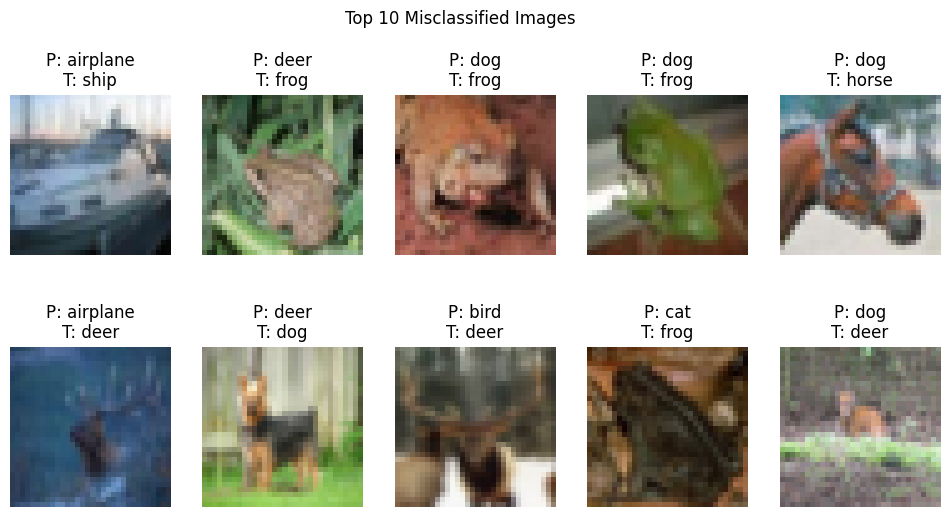

In [ ]:
misclassified = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(12, 6))

for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"P: {class_names[pred_labels[idx]]}\nT: {class_names[true_labels[idx]]}")
    plt.axis("off")

plt.suptitle("Top 10 Misclassified Images")
plt.show()

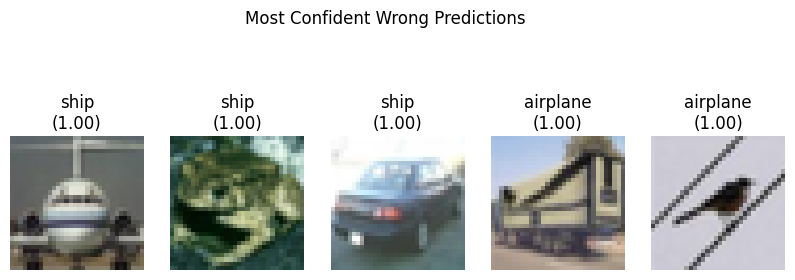

In [ ]:
confidence = np.max(pred_probs, axis=1)
wrong_confidence = confidence[misclassified]

top_wrong = misclassified[np.argsort(-wrong_confidence)[:5]]

plt.figure(figsize=(10, 4))

for i, idx in enumerate(top_wrong):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"{class_names[pred_labels[idx]]}\n({confidence[idx]:.2f})")
    plt.axis("off")

plt.suptitle("Most Confident Wrong Predictions")
plt.show()